Simulation to model muons emitted from a square source (x,y) with an angle taken from a cos^2 distribution. 

These trajectories were followed through a sphere beneath the source and the distance travelled within the sphere outputted.

say square is at z=0 position and the sphere centre is at (0,0,z=-d) position where d can be changed. 

square dimensions of 30x30cm and sphere has 30cm diameter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Theta is the angle from the vertical.

Uniformly pick theta values from -pi/2 to pi/2

sub into PDF normalised from -pi/2 to pi/2: $f(\theta)= \frac{2}{\pi} cos^2 \theta$

pick another number, n, between 0 and 1,
keep theta if n $<cos^2\theta$

In [2]:
N=1000000
square_length = 300 #in cm
sphere_centre = np.array([0,0,-15]) #in cm
sphere_radius = 15 #in cm

x0 = np.zeros(N)
y0 = np.zeros(N)
z0 = np.zeros(N)
theta = np.zeros(N)
phi = np.zeros(N)
dx = np.zeros(N)
dy = np.zeros(N)
dz = np.zeros(N)
b = np.zeros(N)
chord = np.zeros(N)


for muon in range(N):
    x0[muon] = np.random.uniform(-square_length/2, square_length/2)
    y0[muon] = np.random.uniform(-square_length/2, square_length/2)
    z0[muon] = 0


    #angles
    accepted = False
    while not accepted:
        theta_trial = np.random.uniform(-np.pi/2, np.pi/2)
        n = np.random.uniform(0, 1)

        if n < (2/np.pi) * np.cos(theta_trial)**2:
            theta[muon] = theta_trial
            accepted = True

    phi[muon] = np.random.uniform(0,2*np.pi)
    #theta[muon] = 0
    #directions
    dx[muon] = np.sin(theta[muon])*np.cos(phi[muon])
    dy[muon] = np.sin(theta[muon])*np.sin(phi[muon])
    dz[muon] = -np.cos(theta[muon])


    #origins = (x0,y0,z0=0) = O
    #directions = (dx,dy,dz) = D
    #sphere centre = (0,0,-d) 
    O = np.array([x0[muon], y0[muon], z0[muon]])
    D = np.array([dx[muon], dy[muon], dz[muon]])
    O_C = O - sphere_centre

    b[muon] = np.linalg.norm(np.cross(O_C, D))

    chord[muon] = 0

    if b[muon] < sphere_radius:
        chord[muon] = 2*np.sqrt(sphere_radius**2 - b[muon]**2)
    else:
        chord[muon] = 0        
    


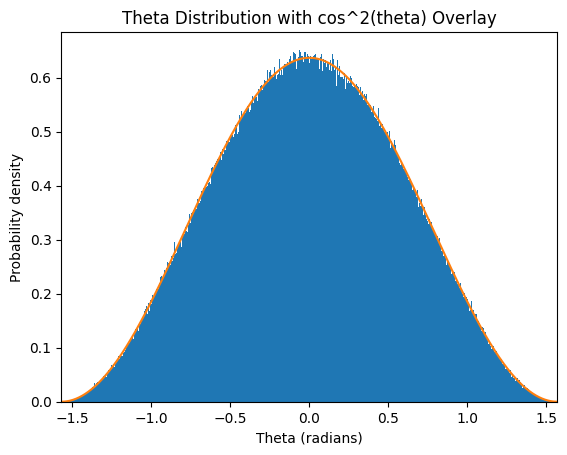

In [3]:
plt.figure()
plt.hist(theta, bins=500, density=True)

# Overlay cos^2(theta)
theta_vals = np.linspace(-np.pi/2, np.pi/2, 1000)
plt.plot(theta_vals, 2/np.pi * np.cos(theta_vals)**2)

plt.xlabel("Theta (radians)")
plt.ylabel("Probability density")
plt.title("Theta Distribution with cos^2(theta) Overlay")
plt.xlim(-np.pi/2, np.pi/2)
plt.show()

In [4]:
#print the simulated events into a table

df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b
})

print(df.head())
print(np.sum(chord > 0))

       x (cm)     y (cm)  z (cm)  theta (rad)  phi (rad)  chord length (cm)  \
0 -141.515768  28.273964     0.0    -0.796957   0.202867           0.000000   
1  131.841088  30.446871     0.0     0.533364   1.358687           0.000000   
2    1.583552  -6.967356     0.0     0.831718   2.423425          24.944352   
3  -88.604556  98.352247     0.0     0.072243   5.438869           0.000000   
4 -103.225715 -32.380655     0.0    -1.184728   0.457769           0.000000   

   closest approach to sphere centre  
0                         117.884620  
1                         135.157183  
2                           8.333356  
3                         130.950034  
4                          56.631639  
10066


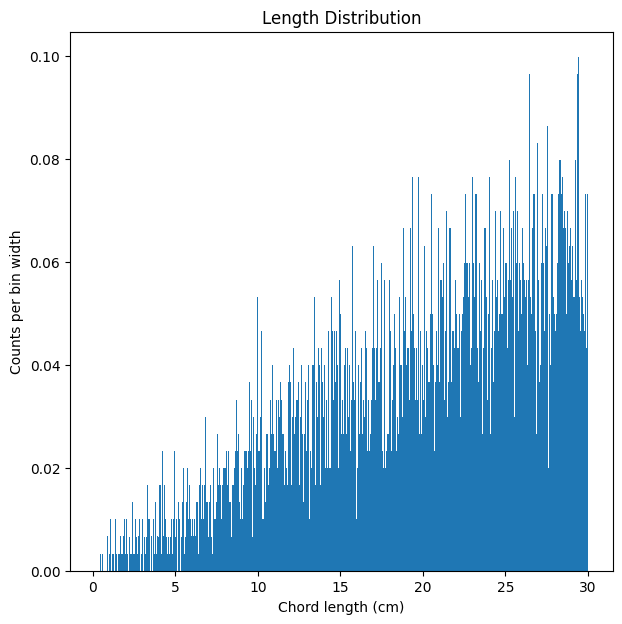

In [5]:
plt.figure(figsize=(7,7))
plt.hist(chord[chord > 0], bins=1000, density=True)
plt.xlabel("Chord length (cm)")
plt.ylabel("Counts per bin width")
plt.title("Length Distribution")
plt.show()

Now analyse the amount of energy deposited in the sphere by the muons.

Find this per muon and in total. 

This will be dependent on the gas in the sphere, Nitrogen, the pressure, say 1bar, and the chord length of the muon in the sphere. 



Mass stopping power for cosmic ray muons (MIPS):

$\frac{1}{\rho}\frac{dE}{dx}=2MeV/(g/cm^2)$

find density of Nitrogen:

$pV=nRT$

$n = \frac{m}{M_r}$

$pV = \frac{m}{M_r}RT$

$\rho = \frac{m}{V}$

so: $\rho = \frac{PM_r}{RT}$


In [17]:
pressure_bar = 0.5 #in bars
pressure_pa = pressure_bar*(1e5)
room_temp = 293 #in Kelvin
#gas_A = 28 #for N_2
gas_A = 39.52 #for argon methane

dEdx_mass = 2 #MeV/gcm^2

density = (pressure_pa*gas_A)/(8.31*room_temp) / (1e6)

dEdx = dEdx_mass * density

print(dEdx,"MeV/cm")
print(dEdx*1000,"keV/cm")


0.0016231112644414603 MeV/cm
1.6231112644414603 keV/cm


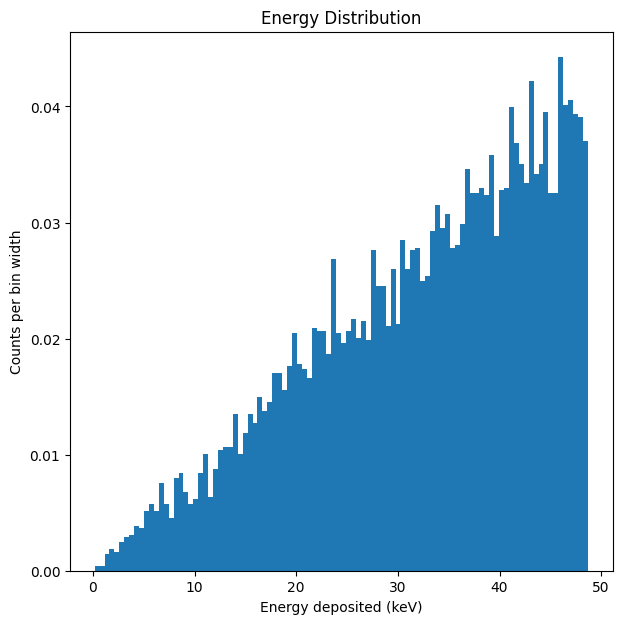

In [7]:
#multiply dE/dx by length to find dE deposited
energy_dep = dEdx * chord
plt.figure(figsize=(7,7))
plt.hist(energy_dep[energy_dep > 0]*1000, bins=100, density=True)
plt.xlabel("Energy deposited (keV)")
plt.ylabel("Counts per bin width")
plt.title("Energy Distribution")
plt.show()


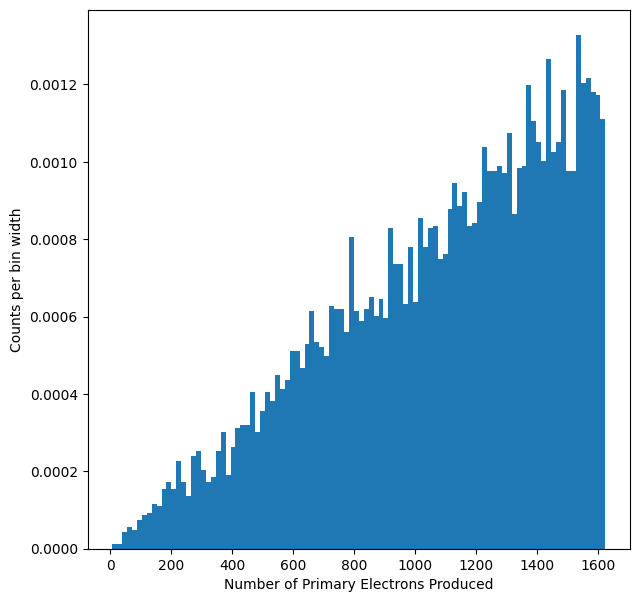

In [8]:
#use W-value to get average electrons produced, say W ~ 30eV
energy_dep_eV = energy_dep*1e6

N_primary_electrons = energy_dep_eV / 30 

plt.figure(figsize=(7,7))
plt.hist(N_primary_electrons[N_primary_electrons > 0], bins=100, density=True)
plt.xlabel("Number of Primary Electrons Produced")
plt.ylabel("Counts per bin width")
plt.show()


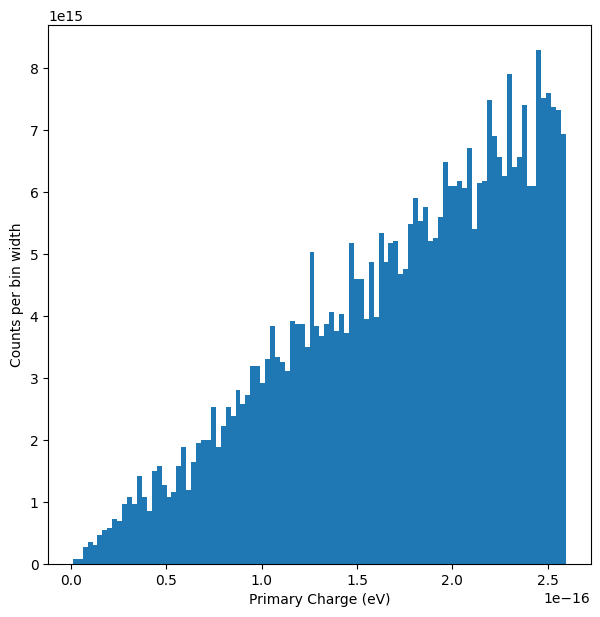

In [9]:
#convert to charge
primary_charge = N_primary_electrons * (1.6e-19)

plt.figure(figsize=(7,7))
plt.hist(primary_charge[primary_charge > 0], bins=100, density=True)
plt.xlabel("Primary Charge (eV)")
plt.ylabel("Counts per bin width")
plt.show()


Can get gain factor from Pete - multiply primary by gain factor to get charge collected at anode, then can convert to voltage readout

       x (cm)     y (cm)  z (cm)  theta (rad)  phi (rad)  chord length (cm)  \
0 -141.515768  28.273964     0.0    -0.796957   0.202867           0.000000   
1  131.841088  30.446871     0.0     0.533364   1.358687           0.000000   
2    1.583552  -6.967356     0.0     0.831718   2.423425          24.944352   
3  -88.604556  98.352247     0.0     0.072243   5.438869           0.000000   
4 -103.225715 -32.380655     0.0    -1.184728   0.457769           0.000000   

   closest approach to sphere centre  veto trigger  
0                         117.884620         False  
1                         135.157183         False  
2                           8.333356         False  
3                         130.950034         False  
4                          56.631639         False  
configuration: sandwich, aligned
number intersected sphere: 10066
number passed through veto: 4785
number passed through veto and sphere: 1062
number in veto but not sphere: 3723


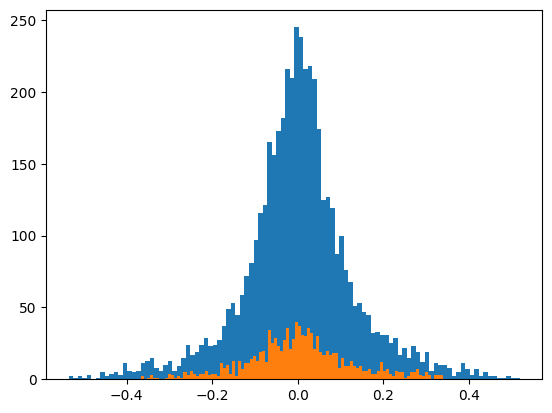

In [10]:
#add veto system

#sandwich configuration - above and below sphere ALIGNED

scintillator1_pos = np.array([0,0,0])
scintillator2_pos = np.array([0,0,-220])
scint_width = 25
scint_length = 135
scint_thickness = 1

veto_trigger = np.zeros(N, dtype=bool)
for muon in range(N):
    # intersection with scintillator 1
    t1 = (scintillator1_pos[2] - z0[muon]) / dz[muon]
    x1 = x0[muon] + t1*dx[muon]
    y1 = y0[muon] + t1*dy[muon]

    hit1 = False
    if abs(x1) < scint_width/2 and abs(y1) < scint_length/2:
        hit1 = True

    # intersection with scintillator 2
    t2 = (scintillator2_pos[2] - z0[muon]) / dz[muon]
    x2 = x0[muon] + t2*dx[muon]
    y2 = y0[muon] + t2*dy[muon]

    hit2 = False
    if abs(x2) < scint_width/2 and abs(y2) < scint_length/2:
        hit2 = True

    # coincidence
    if hit1 and hit2:
        veto_trigger[muon] = True
        


df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b,
    "veto trigger": veto_trigger
})

print(df.head())

print('configuration: sandwich, aligned')

print('number intersected sphere:', np.sum(chord > 0))
print('number passed through veto:', np.sum(veto_trigger == True))


veto_and_sphere = (chord > 0) & veto_trigger
print('number passed through veto and sphere:', np.sum(veto_and_sphere))

print('number in veto but not sphere:', np.sum(veto_trigger == True)-np.sum(veto_and_sphere))
plt.hist(df['theta (rad)'][veto_trigger==True], bins=100)
plt.hist(df['theta (rad)'][veto_and_sphere==True], bins=100)

sandwich_parallel_veto = veto_trigger
sandwich_parallel_veto_and_sphere = veto_and_sphere

       x (cm)     y (cm)  z (cm)  theta (rad)  phi (rad)  chord length (cm)  \
0 -141.515768  28.273964     0.0    -0.796957   0.202867           0.000000   
1  131.841088  30.446871     0.0     0.533364   1.358687           0.000000   
2    1.583552  -6.967356     0.0     0.831718   2.423425          24.944352   
3  -88.604556  98.352247     0.0     0.072243   5.438869           0.000000   
4 -103.225715 -32.380655     0.0    -1.184728   0.457769           0.000000   

   closest approach to sphere centre  veto trigger  
0                         117.884620         False  
1                         135.157183         False  
2                           8.333356         False  
3                         130.950034         False  
4                          56.631639         False  
configuration: sandwich, perpendicular
number intersected sphere: 10066
number passed through veto: 6641
number passed through veto and sphere: 4103
number in veto but not sphere: 2538


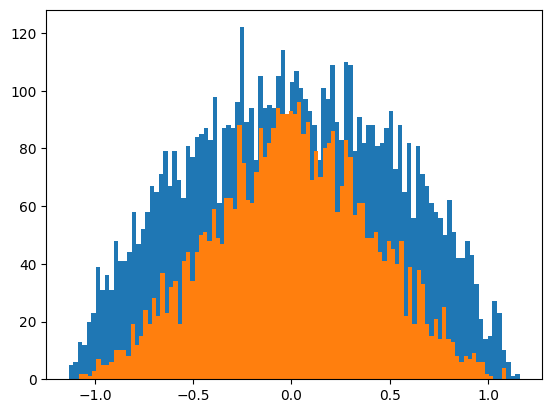

In [11]:
#add veto system

#sandwich configuration - above and below sphere PERPENDICULAR

scintillator1_pos = np.array([0,0,-10])
scintillator2_pos = np.array([0,0,-50])
scint_width = 25
scint_length = 135
scint_thickness = 1

veto_trigger = np.zeros(N, dtype=bool)
for muon in range(N):
    # intersection with scintillator 1
    t1 = (scintillator1_pos[2] - z0[muon]) / dz[muon]
    x1 = x0[muon] + t1*dx[muon]
    y1 = y0[muon] + t1*dy[muon]

    hit1 = False
    if abs(x1) < scint_width/2 and abs(y1) < scint_length/2:
        hit1 = True

    # intersection with scintillator 2
    t2 = (scintillator2_pos[2] - z0[muon]) / dz[muon]
    x2 = x0[muon] + t2*dx[muon]
    y2 = y0[muon] + t2*dy[muon]

    hit2 = False
    if abs(x2) < scint_length/2 and abs(y2) < scint_width/2:
        hit2 = True

    # coincidence
    if hit1 and hit2:
        veto_trigger[muon] = True
        


df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b,
    "veto trigger": veto_trigger
})

print(df.head())

print('configuration: sandwich, perpendicular')
print('number intersected sphere:', np.sum(chord > 0))
print('number passed through veto:', np.sum(veto_trigger == True))


veto_and_sphere = (chord > 0) & veto_trigger
print('number passed through veto and sphere:', np.sum(veto_and_sphere))

print('number in veto but not sphere:', np.sum(veto_trigger == True)-np.sum(veto_and_sphere))
plt.hist(df['theta (rad)'][veto_trigger==True], bins=100)
plt.hist(df['theta (rad)'][veto_and_sphere==True], bins=100)

sandwich_perp_veto = veto_trigger
sandwich_perp_veto_and_sphere = veto_and_sphere

In [12]:
#two layer on bottom ALIGNED
scintillator1_pos = np.array([0,0,-90])
scintillator2_pos = np.array([0,0,-97])
scint_width = 25
scint_length = 135
scint_thickness = 1


veto_trigger = np.zeros(N, dtype=bool)
for muon in range(N):
    # intersection with scintillator 1
    t1 = (scintillator1_pos[2] - z0[muon]) / dz[muon]
    x1 = x0[muon] + t1*dx[muon]
    y1 = y0[muon] + t1*dy[muon]

    hit1 = False
    if abs(x1) < scint_width/2 and abs(y1) < scint_length/2:
        hit1 = True

    # intersection with scintillator 2
    t2 = (scintillator2_pos[2] - z0[muon]) / dz[muon]
    x2 = x0[muon] + t2*dx[muon]
    y2 = y0[muon] + t2*dy[muon]

    hit2 = False
    if abs(x2) < scint_width/2 and abs(y2) < scint_length/2:
        hit2 = True

    # coincidence
    if hit1 and hit2:
        veto_trigger[muon] = True
        


df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b,
    "veto trigger": veto_trigger
})

print(df.head())

print('configuration: both below, aligned')
print('number intersected sphere:', np.sum(chord > 0))
print('number passed through veto:', np.sum(veto_trigger == True))


veto_and_sphere = (chord > 0) & veto_trigger
print('number passed through veto and sphere:', np.sum(veto_and_sphere))

print('number in veto but not sphere:', np.sum(veto_trigger == True)-np.sum(veto_and_sphere))

below_parallel_veto = veto_trigger
below_parallel_veto_and_sphere = veto_and_sphere

       x (cm)     y (cm)  z (cm)  theta (rad)  phi (rad)  chord length (cm)  \
0 -141.515768  28.273964     0.0    -0.796957   0.202867           0.000000   
1  131.841088  30.446871     0.0     0.533364   1.358687           0.000000   
2    1.583552  -6.967356     0.0     0.831718   2.423425          24.944352   
3  -88.604556  98.352247     0.0     0.072243   5.438869           0.000000   
4 -103.225715 -32.380655     0.0    -1.184728   0.457769           0.000000   

   closest approach to sphere centre  veto trigger  
0                         117.884620         False  
1                         135.157183         False  
2                           8.333356         False  
3                         130.950034         False  
4                          56.631639         False  
configuration: both below, aligned
number intersected sphere: 10066
number passed through veto: 31518
number passed through veto and sphere: 2682
number in veto but not sphere: 28836


       x (cm)     y (cm)  z (cm)  theta (rad)  phi (rad)  chord length (cm)  \
0 -141.515768  28.273964     0.0    -0.796957   0.202867           0.000000   
1  131.841088  30.446871     0.0     0.533364   1.358687           0.000000   
2    1.583552  -6.967356     0.0     0.831718   2.423425          24.944352   
3  -88.604556  98.352247     0.0     0.072243   5.438869           0.000000   
4 -103.225715 -32.380655     0.0    -1.184728   0.457769           0.000000   

   closest approach to sphere centre  veto trigger  
0                         117.884620         False  
1                         135.157183         False  
2                           8.333356         False  
3                         130.950034         False  
4                          56.631639         False  
configuration: both below, perpendicular
number intersected sphere: 10066
number passed through veto: 6933
number passed through veto and sphere: 2921
number in veto but not sphere: 4012


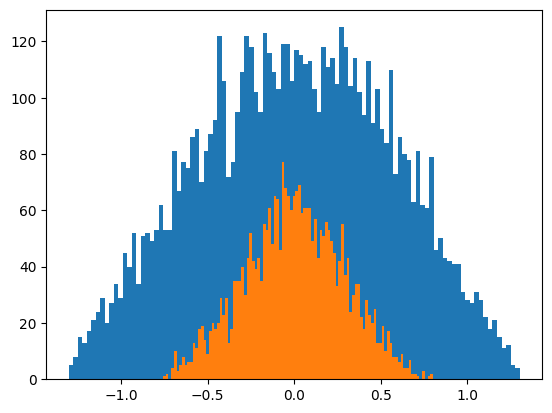

In [13]:
#two layer on bottom PERPENDICULAR
#5cm and 6cm below bottom of sphere
scintillator1_pos = np.array([0,0,-50])
scintillator2_pos = np.array([0,0,-51])
scint_width = 25
scint_length = 135
scint_thickness = 1


veto_trigger = np.zeros(N, dtype=bool)
for muon in range(N):
    # intersection with scintillator 1
    t1 = (scintillator1_pos[2] - z0[muon]) / dz[muon]
    x1 = x0[muon] + t1*dx[muon]
    y1 = y0[muon] + t1*dy[muon]

    hit1 = False
    if abs(x1) < scint_width/2 and abs(y1) < scint_length/2:
        hit1 = True

    # intersection with scintillator 2
    t2 = (scintillator2_pos[2] - z0[muon]) / dz[muon]
    x2 = x0[muon] + t2*dx[muon]
    y2 = y0[muon] + t2*dy[muon]

    hit2 = False
    if abs(x2) < scint_length/2 and abs(y2) < scint_width/2:        #scintillators perpendicular
        hit2 = True

    # coincidence
    if hit1 and hit2:
        veto_trigger[muon] = True
        


df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b,
    "veto trigger": veto_trigger
})

print(df.head())

print('configuration: both below, perpendicular')
print('number intersected sphere:', np.sum(chord > 0))
print('number passed through veto:', np.sum(veto_trigger == True))


veto_and_sphere = (chord > 0) & veto_trigger
print('number passed through veto and sphere:', np.sum(veto_and_sphere))

print('number in veto but not sphere:', np.sum(veto_trigger == True)-np.sum(veto_and_sphere))

plt.hist(df['theta (rad)'][veto_trigger==True], bins=100)
plt.hist(df['theta (rad)'][veto_and_sphere==True], bins=100)


below_perp_veto = veto_trigger
below_perp_veto_and_sphere = veto_and_sphere

4103
2921


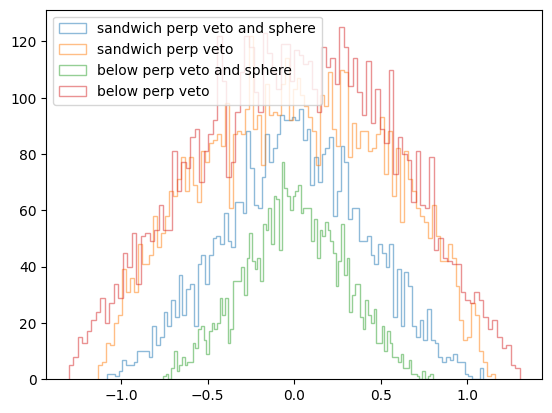

In [14]:
plt.hist(df['theta (rad)'][sandwich_perp_veto_and_sphere==True], bins=100, alpha = 0.5,label = 'sandwich perp veto and sphere',histtype='step')
plt.hist(df['theta (rad)'][sandwich_perp_veto==True], bins=100,alpha = 0.5, label = 'sandwich perp veto',histtype='step')
plt.hist(df['theta (rad)'][below_perp_veto_and_sphere==True], bins=100,alpha = 0.5, label = 'below perp veto and sphere',histtype='step')
plt.hist(df['theta (rad)'][below_perp_veto==True], bins=100,alpha = 0.5, label = 'below perp veto',histtype='step')
plt.legend()

print(np.sum(sandwich_perp_veto_and_sphere==True))
print(np.sum(below_perp_veto_and_sphere==True))